In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
from scipy.stats import expon, norm, kstest, chi2, f_oneway, pearsonr, chisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

In [214]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

LAMBDA = 8    # pacjenci na godzinę
MU = 3        # pacjenci obsłużeni przez lekarza na godzinę  
C = 3         # liczba lekarzy

In [215]:
df = pd.read_csv('wyniki_symulacji.csv')

### Testy normalności czasów oczekiwania

Hipotezy:
- H₀ (hipoteza zerowa): Czasy oczekiwania mają rozkład normalny
- H₁ (hipoteza alternatywna): Czasy oczekiwania NIE mają rozkładu normalnego

In [216]:
# Test Shapiro-Wilka
stat_shapiro, p_shapiro = stats.shapiro(df['Czas_oczekiwania'])
print(f"\n1) Test Shapiro-Wilka:")
print(f"   - Statystyka testowa W: {stat_shapiro:.4f}")
print(f"   - p-wartość: {p_shapiro:.4f}")
print(f"   - Decyzja: {'ODRZUCAMY H₀' if p_shapiro < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"   - Interpretacja: Czasy oczekiwania {'NIE MAJĄ' if p_shapiro < 0.05 else 'MAJĄ'} rozkładu normalnego")


1) Test Shapiro-Wilka:
   - Statystyka testowa W: 0.7402
   - p-wartość: 0.0000
   - Decyzja: ODRZUCAMY H₀
   - Interpretacja: Czasy oczekiwania NIE MAJĄ rozkładu normalnego


In [217]:
# Test Kołmogorowa-Smirnowa
stat_ks, p_ks = stats.kstest(df['Czas_oczekiwania'], 'norm', 
                             args=(df['Czas_oczekiwania'].mean(), 
                                   df['Czas_oczekiwania'].std()))
print(f"\n2) Test Kołmogorowa-Smirnowa:")
print(f"   - Statystyka testowa D: {stat_ks:.4f}")
print(f"   - p-wartość: {p_ks:.4f}")
print(f"   - Decyzja: {'ODRZUCAMY H₀' if p_ks < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"   - Interpretacja: Czasy oczekiwania {'NIE MAJĄ' if p_ks < 0.05 else 'MAJĄ'} rozkładu normalnego")


2) Test Kołmogorowa-Smirnowa:
   - Statystyka testowa D: 0.2265
   - p-wartość: 0.0000
   - Decyzja: ODRZUCAMY H₀
   - Interpretacja: Czasy oczekiwania NIE MAJĄ rozkładu normalnego


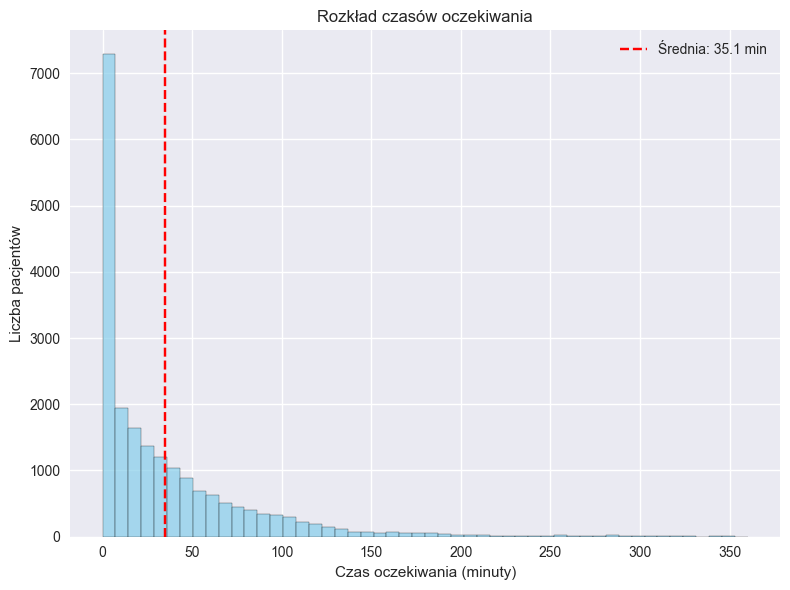

In [218]:
plt.show()
plt.figure(figsize=(8, 6))
plt.hist(df['Czas_oczekiwania'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Rozkład czasów oczekiwania')
plt.xlabel('Czas oczekiwania (minuty)')
plt.ylabel('Liczba pacjentów')
plt.axvline(df['Czas_oczekiwania'].mean(), color='red', linestyle='--', 
            label=f'Średnia: {df["Czas_oczekiwania"].mean():.1f} min')
plt.legend()
plt.tight_layout()
plt.show()

### Testy jednorodności - porównanie efektywności lekarzy

In [219]:
print("\nHIPOTEZY:")
print("H₀: Średnie czasy oczekiwania są równe dla wszystkich lekarzy")
print("H₁: Przynajmniej jeden lekarz ma inną średnią czasów oczekiwania")
print("\nPoziom istotności: α = 0.05")

print("\nStatystyki per lekarz:")
doctor_stats = df.groupby('Lekarz')['Czas_oczekiwania'].agg(['count', 'mean', 'std', 'min', 'max'])
print(doctor_stats)

waiting_times_by_doctor = [group['Czas_oczekiwania'].values 
                          for _, group in df.groupby('Lekarz')]

h_stat, p_kruskal = stats.kruskal(*waiting_times_by_doctor)
print(f"\nTest Kruskala-Wallisa:")
print(f"- Statystyka H: {h_stat:.4f}")
print(f"- p-wartość: {p_kruskal:.4f}")
print(f"- Decyzja: {'ODRZUCAMY H₀' if p_kruskal < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"- Interpretacja: Lekarze {'RÓŻNIĄ SIĘ' if p_kruskal < 0.05 else 'NIE RÓŻNIĄ SIĘ'} pod względem rozkładów czasów oczekiwania")



HIPOTEZY:
H₀: Średnie czasy oczekiwania są równe dla wszystkich lekarzy
H₁: Przynajmniej jeden lekarz ma inną średnią czasów oczekiwania

Poziom istotności: α = 0.05

Statystyki per lekarz:
        count       mean        std  min         max
Lekarz                                              
1        6741  35.713048  47.806928  0.0  352.774505
2        6912  35.060725  45.594546  0.0  354.218973
3        6789  34.576173  46.994478  0.0  360.151533

Test Kruskala-Wallisa:
- Statystyka H: 3.5965
- p-wartość: 0.1656
- Decyzja: NIE ODRZUCAMY H₀
- Interpretacja: Lekarze NIE RÓŻNIĄ SIĘ pod względem rozkładów czasów oczekiwania


### Test zgodności czasów obsługi z rozkładem wykładniczym

In [220]:
df['Czas_obslugi'] = df['Czas_zakonczenia_badania'] - df['Czas_rozpoczecia_badania']

print("\nHIPOTEZY:")
print("H₀: Czasy obsługi mają rozkład wykładniczy z parametrem")
print("H₁: Czasy obsługi NIE mają rozkładu wykładniczego")
print("\nPoziom istotności: α = 0.05")

theoretical_mean = 60 / MU  

ks_stat, ks_p = kstest(df['Czas_obslugi'], 'expon' , args=(0, 60/MU))
print(f"\nTest Kołmogorowa-Smirnowa:")
print(f"- Statystyka testowa D: {ks_stat:.4f}")
print(f"- p-wartość: {ks_p:.4f}")
print(f"- Decyzja: {'ODRZUCAMY H₀' if ks_p < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"- Interpretacja: Czasy obsługi {'NIE MAJĄ' if ks_p < 0.05 else 'MAJĄ'} rozkład wykładniczy")
    


HIPOTEZY:
H₀: Czasy obsługi mają rozkład wykładniczy z parametrem
H₁: Czasy obsługi NIE mają rozkładu wykładniczego

Poziom istotności: α = 0.05

Test Kołmogorowa-Smirnowa:
- Statystyka testowa D: 0.0065
- p-wartość: 0.3577
- Decyzja: NIE ODRZUCAMY H₀
- Interpretacja: Czasy obsługi MAJĄ rozkład wykładniczy


In [221]:
interarrival_times = []
    
for day, day_data in df.groupby('Dzien'):
    day_sorted = day_data.sort_values('Czas_przyjscia')
        
    if 'Czas_przyjscia_exact' in day_sorted.columns:
        arrival_times = day_sorted['Czas_przyjscia_exact'].values
    else:
        arrival_times = day_sorted['Czas_przyjscia'].values
        
    if len(arrival_times) > 1:
        day_interarrival = np.diff(arrival_times)
        interarrival_times.extend(day_interarrival)
    
interarrival_times = np.array(interarrival_times)
    
    
mean_interarrival = np.mean(interarrival_times)
std_interarrival = np.std(interarrival_times)
    
theoretical_mean = 60 / LAMBDA  
theoretical_std = 60 / LAMBDA   


print("\nHIPOTEZY:")
print("H₀: Czasy między przybyciami mają rozkład wykładniczy")
print("H₁: Czasy między przybyciami NIE mają rozkładu wykładniczego")
print("\nPoziom istotności: α = 0.05")

ks_stat, ks_p = kstest(interarrival_times, 'expon', args=(0, theoretical_mean))
    
print(f"\nTest Kołmogorowa-Smirnowa:")
print(f"- Statystyka testowa D: {ks_stat:.4f}")
print(f"- p-wartość: {ks_p:.4f}")
print(f"- Poziom istotności: α = 0.05")
print(f"- Decyzja: {'ODRZUCAMY H₀' if ks_p < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"- Interpretacja: Czasy między przybyciami {'NIE MAJĄ' if ks_p < 0.05 else 'MAJĄ'} rozkład wykładniczy")


HIPOTEZY:
H₀: Czasy między przybyciami mają rozkład wykładniczy
H₁: Czasy między przybyciami NIE mają rozkładu wykładniczego

Poziom istotności: α = 0.05

Test Kołmogorowa-Smirnowa:
- Statystyka testowa D: 0.0076
- p-wartość: 0.1906
- Poziom istotności: α = 0.05
- Decyzja: NIE ODRZUCAMY H₀
- Interpretacja: Czasy między przybyciami MAJĄ rozkład wykładniczy


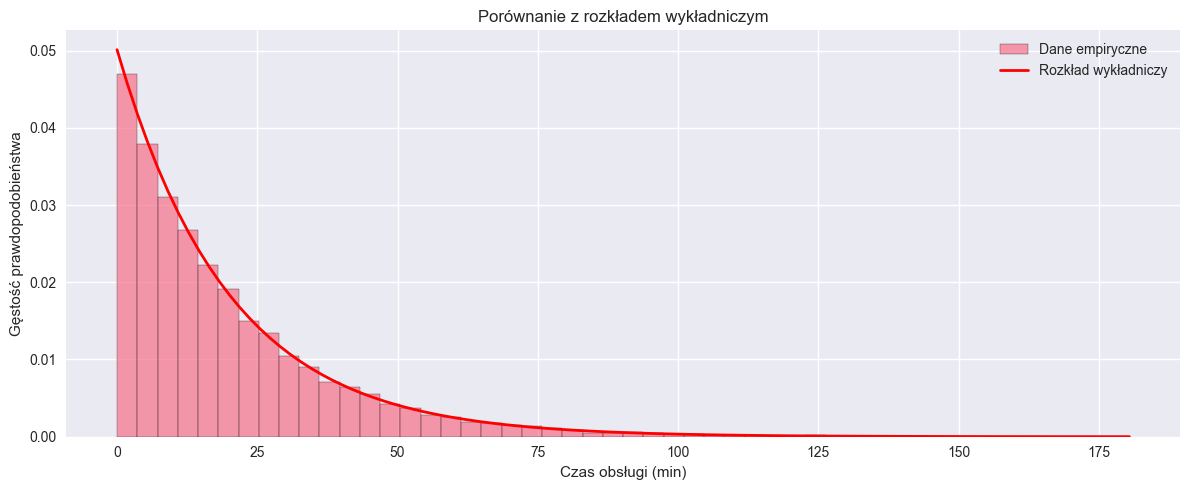

In [222]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 5))

# Histogram z dopasowanym rozkładem wykładniczym
ax1.hist(df['Czas_obslugi'], bins=50, density=True, alpha=0.7,
         edgecolor='black', label='Dane empiryczne')

x = np.linspace(0, df['Czas_obslugi'].max(), 100)
ax1.plot(x, expon.pdf(x, scale=df['Czas_obslugi'].mean()),
         'r-', lw=2, label='Rozkład wykładniczy')

ax1.set_xlabel('Czas obsługi (min)')
ax1.set_ylabel('Gęstość prawdopodobieństwa')
ax1.set_title('Porównanie z rozkładem wykładniczym')
ax1.legend()

plt.tight_layout()
plt.show()

### Test chi-kwadrat dla rozkładu długości kolejki

In [223]:
print("\nHIPOTEZY:")
print("H₀: Długości kolejek w momencie przyjścia mają rozkład jednostajny")
print("H₁: Długości kolejek w momencie przyjścia nie mają rozkładu jednostajnego")

dlugosc_kolejki = df["Dlugosc_kolejki_w_momencie_przyjscia"]
obserwowane = dlugosc_kolejki.value_counts().sort_index()

spodziewane = [len(dlugosc_kolejki) / len(obserwowane)] * len(obserwowane)


chi2_stat, chi2_p = chisquare(f_obs=obserwowane, f_exp=spodziewane)
print("\nTest chi-kwadrat:")
print(f"χ² = {chi2_stat:.4f}, p-wartość = {chi2_p:.5f}")

print(f"- Decyzja: {'ODRZUCAMY H₀' if chi2_p < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"- Interpretacja: Długości kolejek w momencie przyjścia {'NIE MAJĄ' if chi2_p < 0.05 else 'MAJĄ'} rozkładu jednostajnego")


HIPOTEZY:
H₀: Długości kolejek w momencie przyjścia mają rozkład jednostajny
H₁: Długości kolejek w momencie przyjścia nie mają rozkładu jednostajnego

Test chi-kwadrat:
χ² = 136479.6413, p-wartość = 0.00000
- Decyzja: ODRZUCAMY H₀
- Interpretacja: Długości kolejek w momencie przyjścia NIE MAJĄ rozkładu jednostajnego


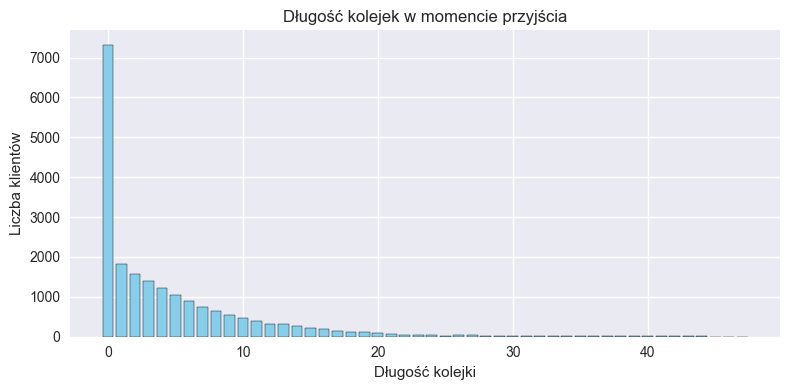

In [224]:
plt.figure(figsize=(8, 4))
plt.bar(obserwowane.index, obserwowane.values, color='skyblue', edgecolor='black')
plt.title("Długość kolejek w momencie przyjścia")
plt.xlabel("Długość kolejki")
plt.ylabel("Liczba klientów")
plt.tight_layout()
plt.show()